# S-Curve Gradient Field Embedding

Simulation scaffold for fitting a noisy gradient field sampled on an S-curve. We generate an S-curve with intrinsic coordinates `(t, y)`, define a simple nonlinear potential `f(t, y)`, estimate local gradient vectors from noisy scalar observations, and compare position-only fitting against position + gradient fitting.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors

repo_root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "scripts").exists()), None)
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing scripts/ from the current working directory")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from scripts.manfit_ours import manfit_ours
import scripts.scalar_potential_manfit as scalar_potential_manfit
import scripts.velocity_manifold_fitter as velocity_manifold_fitter

scalar_potential_manfit = importlib.reload(scalar_potential_manfit)
velocity_manifold_fitter = importlib.reload(velocity_manifold_fitter)

fit_potential_aware_neighborhoods = scalar_potential_manfit.fit_potential_aware_neighborhoods
fit_self_consistent_gradient_manfit = scalar_potential_manfit.fit_self_consistent_gradient_manfit
fit_tangent_constrained_scalar = scalar_potential_manfit.fit_tangent_constrained_scalar
format_metric_table = scalar_potential_manfit.format_metric_table
summarize_fit_errors = scalar_potential_manfit.summarize_fit_errors
VelocityManifoldFitter = velocity_manifold_fitter.VelocityManifoldFitter

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RUN_EXTENDED_SIMULATIONS = False
RUN_TANGENT_PARAMETER_CHECK = False


## Data-Generating Process

The clean manifold is the usual 3D S-curve,

`S(t, y) = [sin(t), y, sign(t) * (cos(t) - 1)]`,

with `t in [-1.5 pi, 1.5 pi]` and `y in [0, 2]`. The potential is intentionally arbitrary but smooth enough to have a meaningful gradient field:

`f(t, y) = sin(1.25 t) + 0.35 cos(3 y) + 0.12 t y`.

Because the S-curve parameter directions are orthonormal away from the sign cusp at `t=0`, the ambient 3D gradient is `df/dt * dS/dt + df/dy * dS/dy`.

In [2]:
def normalize_rows(X, eps=1e-12):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def s_curve_embedding(t, y):
    X = np.empty((len(t), 3), dtype=float)
    X[:, 0] = np.sin(t)
    X[:, 1] = y
    X[:, 2] = np.sign(t) * (np.cos(t) - 1.0)
    return X


def s_curve_tangent_t(t):
    dS_dt = np.c_[np.cos(t), np.zeros_like(t), -np.sign(t) * np.sin(t)]
    dS_dt[np.isclose(t, 0.0), 2] = 0.0
    return normalize_rows(dS_dt)


def potential(t, y):
    return np.sin(1.25 * t) + 0.35 * np.cos(3.0 * y) + 0.12 * t * y


def intrinsic_gradient(t, y):
    df_dt = 1.25 * np.cos(1.25 * t) + 0.12 * y
    df_dy = -1.05 * np.sin(3.0 * y) + 0.12 * t
    return np.c_[df_dt, df_dy]


def make_s_curve_data(n=700, point_noise=0.04, scalar_noise=0.02, seed=7):
    rng = np.random.default_rng(seed)
    t = rng.uniform(-1.5 * np.pi, 1.5 * np.pi, size=n)
    y = rng.uniform(0.0, 2.0, size=n)

    position = s_curve_embedding(t, y)
    tangent_t = s_curve_tangent_t(t)
    tangent_y = np.tile([0.0, 1.0, 0.0], (n, 1))
    grad_intrinsic = intrinsic_gradient(t, y)
    gradient = grad_intrinsic[:, [0]] * tangent_t + grad_intrinsic[:, [1]] * tangent_y
    scalar = potential(t, y)

    truth_data = {
        "position": position,
        "scalar": scalar,
        "gradient": gradient,
        "t": t,
        "y": y,
    }

    observed_data = {
        "position": position + rng.normal(scale=point_noise, size=position.shape),
        "scalar": scalar + rng.normal(scale=scalar_noise, size=scalar.shape),
    }

    data_config = {
        "n_samples": n,
        "point_noise_sd": point_noise,
        "scalar_noise_sd": scalar_noise,
        "seed": seed,
    }
    return truth_data, observed_data, data_config


truth_data, observed_data, data_config = make_s_curve_data(point_noise=0.16, scalar_noise=0.16)
data_config


{'n_samples': 700, 'point_noise_sd': 0.16, 'scalar_noise_sd': 0.16, 'seed': 7}

## Local Gradient Estimator

The algorithms only receive `observed_data`, which contains noisy positions and noisy scalar values. We estimate a gradient field from those two observed quantities with a local ridge regression.


In [3]:
def estimate_gradient_from_neighbors(X, values, n_neighbors=42, ridge=5e-2):
    """Estimate an ambient gradient field from positions and scalar values."""
    X = np.asarray(X, dtype=float)
    values = np.asarray(values, dtype=float)
    if X.ndim != 2:
        raise ValueError("X must be a 2D array")
    if values.shape[0] != X.shape[0]:
        raise ValueError("values must have one entry per row of X")

    n_neighbors = min(int(n_neighbors), X.shape[0] - 1)
    nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1).fit(X)
    _, indices = nbrs.kneighbors(X)
    gradients = np.zeros_like(X)
    eye = np.eye(X.shape[1])

    for i, neigh in enumerate(indices[:, 1:]):
        dX = X[neigh] - X[i]
        df = values[neigh] - values[i]
        gradients[i] = np.linalg.solve(dX.T @ dX + ridge * eye, dX.T @ df)

    return gradients

estimated_gradient = estimate_gradient_from_neighbors(
    observed_data["position"],
    observed_data["scalar"],
    n_neighbors=42,
    ridge=5e-2,
)


## Fit Manifolds

`position_fit` consumes only `observed_data["position"]`. `gradient_fit` consumes `observed_data["position"]` and the gradient estimated from `observed_data`; it never sees `truth_data`.

The scalar-potential note also suggests a conservative baseline: `potential_aware_fit` keeps the local geometry step position-based but downweights neighbors with incompatible scalar values. `self_consistent_fit` is the more direct scalar-gradient baseline: it alternates between re-estimating local scalar gradients on the current fitted geometry and running confidence-weighted gradient-aware MANFIT. `tangent_constrained_fit` revisits the note's direct scalar constraint idea as a tuned baseline: local tangent planes are selected by balancing local reconstruction error and local scalar-regression error, without first treating the scalar gradient as observed velocity.


In [4]:
def fit_position_only(X, scalar, sig, gradient_n_neighbors=42, gradient_ridge=5e-2):
    """Run position-only MANFIT, then estimate gradients on the fitted positions."""
    X_fit = manfit_ours(X, sig=sig, sample_init=X)
    V_fit = estimate_gradient_from_neighbors(
        X_fit,
        scalar,
        n_neighbors=gradient_n_neighbors,
        ridge=gradient_ridge,
    )
    return {
        "position": X_fit,
        "gradient": V_fit,
    }


def fit_position_plus_gradient(
    X,
    V,
    k=15,
    T=8,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
    adaptive_variance_threshold=0.85,
    adaptive_d_min=2,
    random_state=0,
):
    """Run gradient-aware manifold fitting from positions and gradient vectors."""
    fitter = VelocityManifoldFitter(
        X,
        V,
        d_mode="adaptive",
        adaptive_variance_threshold=adaptive_variance_threshold,
        adaptive_d_min=adaptive_d_min,
        k=k,
        T=T,
        eta_g=eta_g,
        theta=theta,
        kappa=kappa,
        bandwidth_mode="variable",
        use_PCA=False,
        random_state=random_state,
    )
    result = fitter.fit(update_mode="normal_only", return_dict=True)
    return {
        "position": result["X"],
        "gradient": result["V"],
        "raw_result": result,
    }

position_fit = fit_position_only(
    observed_data["position"],
    observed_data["scalar"],
    sig=data_config["point_noise_sd"],
    gradient_n_neighbors=42,
    gradient_ridge=5e-2,
)

gradient_fit = fit_position_plus_gradient(
    observed_data["position"],
    estimated_gradient,
    k=15,
    T=8,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
)

potential_aware_fit = fit_potential_aware_neighborhoods(
    observed_data["position"],
    observed_data["scalar"],
    k=32,
    T=5,
    eta=0.65,
)

tangent_constrained_fit = fit_tangent_constrained_scalar(
    observed_data["position"],
    observed_data["scalar"],
    k=32,
    T=5,
    eta=0.5,
    scalar_lambda=0.15,
    tangent_candidate_normals=32,
)

self_consistent_no_confidence_fit = fit_self_consistent_gradient_manfit(
    observed_data["position"],
    observed_data["scalar"],
    outer_iterations=4,
    gradient_n_neighbors=42,
    gradient_ridge=5e-2,
    confidence_power=0.0,
    k=15,
    inner_T=2,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
)

self_consistent_fit = fit_self_consistent_gradient_manfit(
    observed_data["position"],
    observed_data["scalar"],
    outer_iterations=4,
    gradient_n_neighbors=42,
    gradient_ridge=5e-2,
    confidence_power=1.0,
    k=15,
    inner_T=2,
    eta_g=0.35,
    theta=0.2,
    kappa=2.0,
)



## Visual and Quantitative Comparison

Rows show the clean ground truth first, then the requested noisy and fitted comparisons. The left column shows the scalar potential; the right column overlays the local or fitted gradient vectors.

The table and bar plots report indexed position RMSE against the clean sample, RMSE to the noiseless S-curve surface, raw mean gradient cosine error, and the same gradient cosine error after projecting each estimated gradient onto a local PCA tangent space estimated from that method's fitted positions.


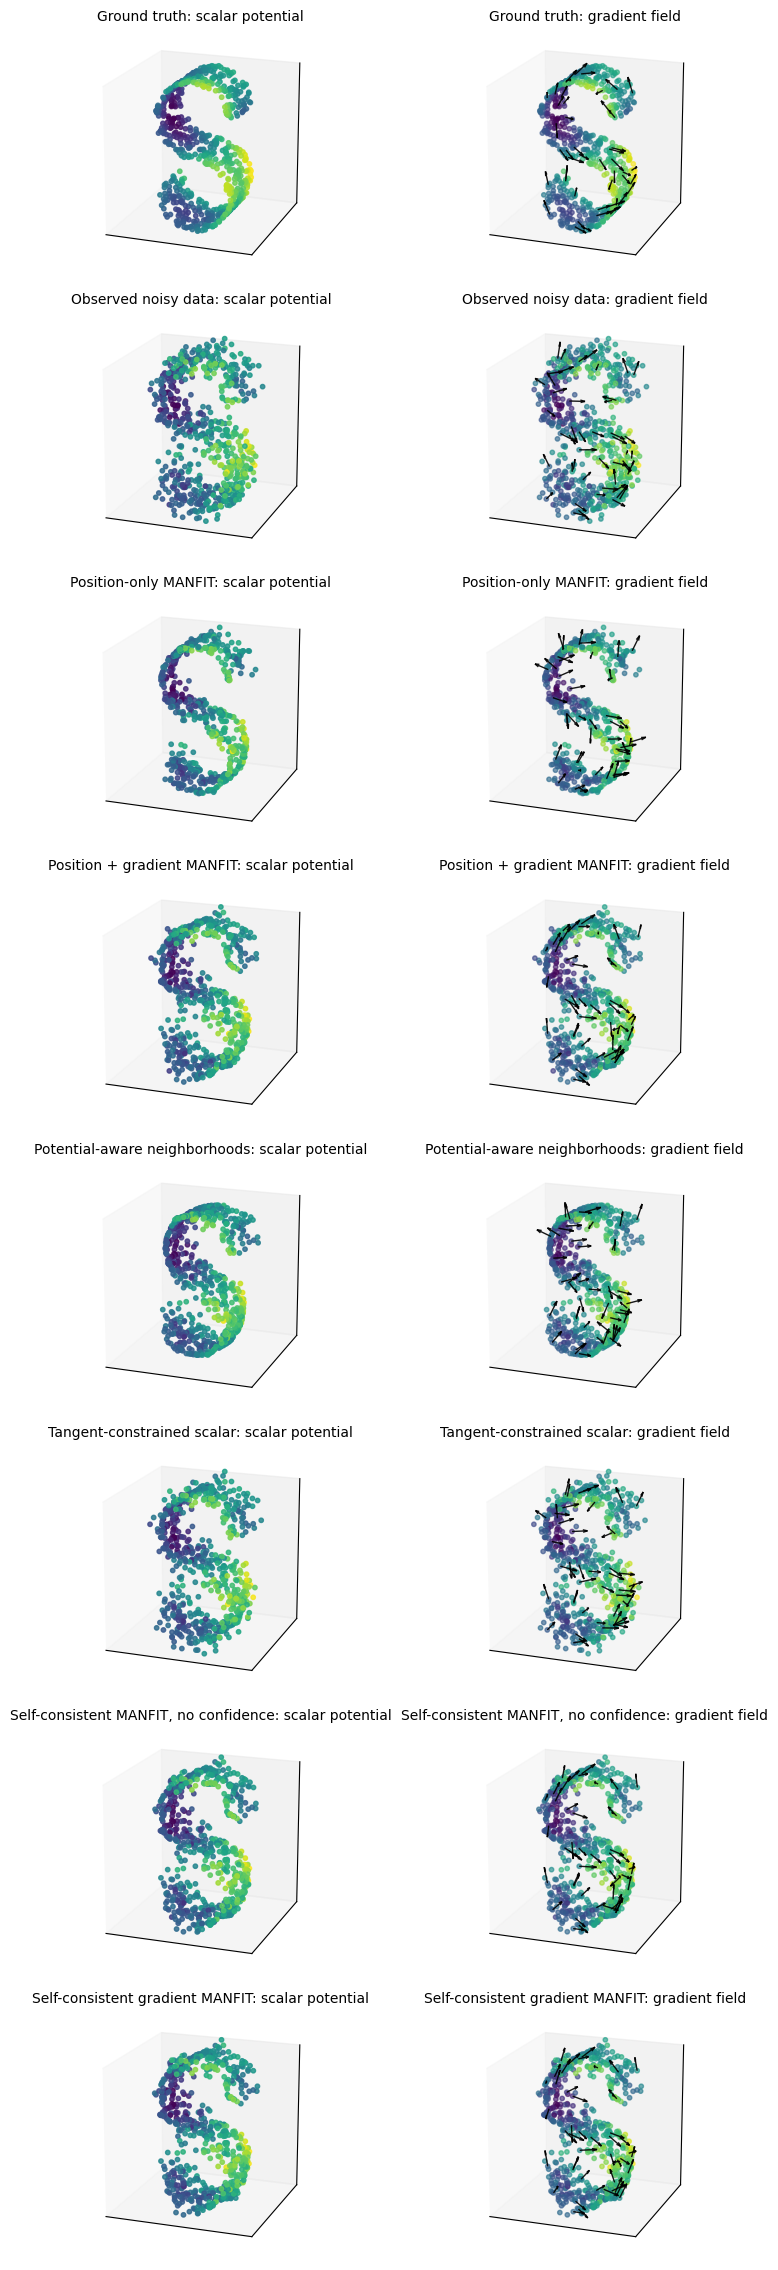

method                                 indexed_position_rmse  s_curve_distance_rmse  gradient_cosine_error  projected_gradient_cosine_error
-------------------------------------  ---------------------  ---------------------  ---------------------  -------------------------------
Observed noisy data                                   0.2789                 0.1625                 0.2232                           0.1344
Position-only MANFIT                                  0.2748                 0.0620                 0.3794                           0.1601
Position + gradient MANFIT                            0.2423                 0.0951                 0.1564                           0.1312
Potential-aware neighborhoods                         0.2514                 0.1265                 0.4405                           0.1237
Tangent-constrained scalar                            0.2521                 0.1116                 0.2838                           0.1212
Self-consistent MANF

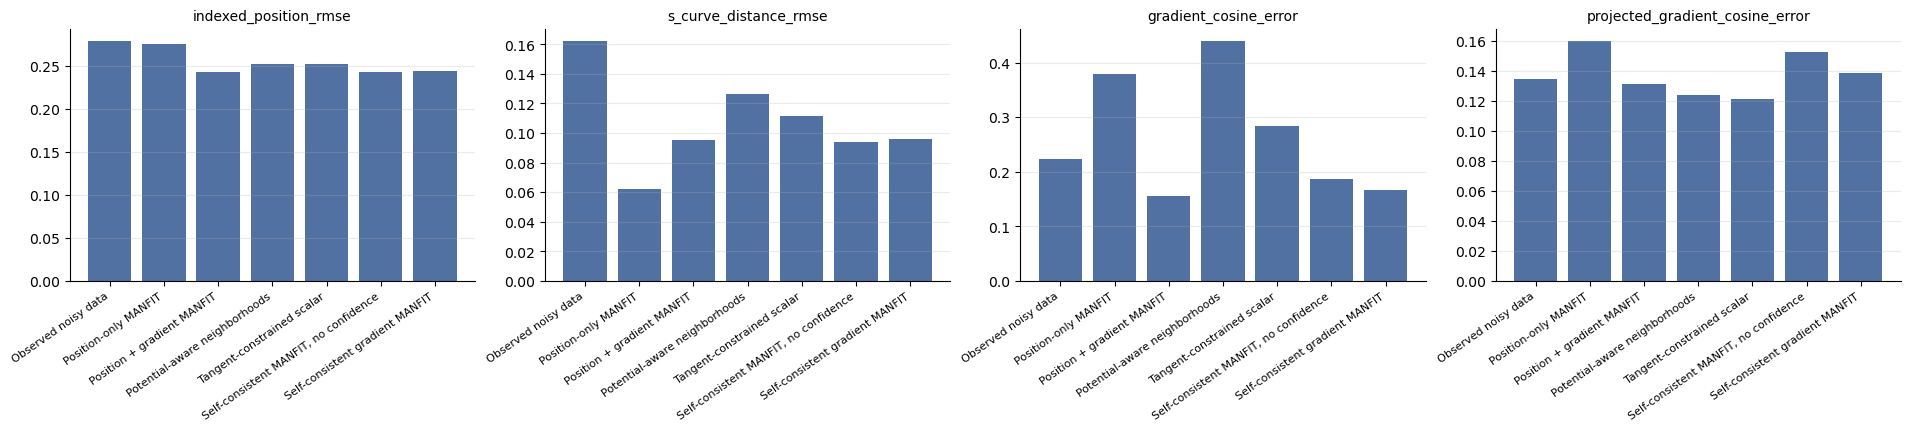

In [5]:
def set_equal_3d_limits(ax, Xref):
    mins = Xref.min(axis=0)
    maxs = Xref.max(axis=0)
    centers = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


def clean_axis(ax):
    ax.view_init(elev=18, azim=-70)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")
    ax.grid(False)


def draw_scalar_panel(ax, Z, color, title):
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=color, cmap="viridis", s=10, alpha=0.85)
    ax.set_title(title, fontsize=10, pad=2)
    set_equal_3d_limits(ax, truth_data["position"])
    clean_axis(ax)


def draw_vector_panel(ax, Z, V, color, title):
    step = max(1, Z.shape[0] // 45)
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=color, cmap="viridis", s=10, alpha=0.65)
    ax.quiver(
        Z[::step, 0], Z[::step, 1], Z[::step, 2],
        V[::step, 0], V[::step, 1], V[::step, 2],
        length=0.45, normalize=True, color="black", linewidth=1.0, alpha=0.9,
    )
    ax.set_title(title, fontsize=10, pad=2)
    set_equal_3d_limits(ax, truth_data["position"])
    clean_axis(ax)


rows = [
    ("Ground truth", truth_data["position"], truth_data["gradient"], truth_data["scalar"]),
    ("Observed noisy data", observed_data["position"], estimated_gradient, observed_data["scalar"]),
    ("Position-only MANFIT", position_fit["position"], position_fit["gradient"], observed_data["scalar"]),
    ("Position + gradient MANFIT", gradient_fit["position"], gradient_fit["gradient"], observed_data["scalar"]),
    ("Potential-aware neighborhoods", potential_aware_fit["position"], potential_aware_fit["gradient"], observed_data["scalar"]),
    ("Tangent-constrained scalar", tangent_constrained_fit["position"], tangent_constrained_fit["gradient"], observed_data["scalar"]),
    ("Self-consistent MANFIT, no confidence", self_consistent_no_confidence_fit["position"], self_consistent_no_confidence_fit["gradient"], observed_data["scalar"]),
    ("Self-consistent gradient MANFIT", self_consistent_fit["position"], self_consistent_fit["gradient"], observed_data["scalar"]),
]

fig = plt.figure(figsize=(9.2, 22.8), constrained_layout=False)
for row_idx, (row_title, Z, V, color) in enumerate(rows):
    ax = fig.add_subplot(len(rows), 2, 2 * row_idx + 1, projection="3d")
    draw_scalar_panel(ax, Z, color, f"{row_title}: scalar potential")

    ax = fig.add_subplot(len(rows), 2, 2 * row_idx + 2, projection="3d")
    draw_vector_panel(ax, Z, V, color, f"{row_title}: gradient field")

fig.tight_layout()
plt.show()

metrics = [
    summarize_fit_errors("Observed noisy data", observed_data["position"], estimated_gradient, truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Position-only MANFIT", position_fit["position"], position_fit["gradient"], truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Position + gradient MANFIT", gradient_fit["position"], gradient_fit["gradient"], truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Potential-aware neighborhoods", potential_aware_fit["position"], potential_aware_fit["gradient"], truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Tangent-constrained scalar", tangent_constrained_fit["position"], tangent_constrained_fit["gradient"], truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Self-consistent MANFIT, no confidence", self_consistent_no_confidence_fit["position"], self_consistent_no_confidence_fit["gradient"], truth_data["position"], truth_data["gradient"]),
    summarize_fit_errors("Self-consistent gradient MANFIT", self_consistent_fit["position"], self_consistent_fit["gradient"], truth_data["position"], truth_data["gradient"]),
]

print(format_metric_table(metrics))

metric_names = ["indexed_position_rmse", "s_curve_distance_rmse", "gradient_cosine_error", "projected_gradient_cosine_error"]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), constrained_layout=True)
x = np.arange(len(metrics))
labels = [row["method"] for row in metrics]
for ax, metric_name in zip(axes, metric_names):
    values = [row[metric_name] for row in metrics]
    ax.bar(x, values, color="#5271a3")
    ax.set_title(metric_name, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
plt.show()


## Multi-Seed Numerical Simulation

Repeat the S-curve experiment across random seeds and summarize error means and standard deviations. This includes a confidence ablation (`confidence_power=0`) to show whether confidence weighting changes the result rather than hiding inside the method.


In [6]:
if RUN_EXTENDED_SIMULATIONS:
    def run_single_s_curve_trial(seed, point_noise=0.16, scalar_noise=0.16, n=700):
        truth, observed, config = make_s_curve_data(
            n=n,
            point_noise=point_noise,
            scalar_noise=scalar_noise,
            seed=seed,
        )
        grad0 = estimate_gradient_from_neighbors(
            observed["position"],
            observed["scalar"],
            n_neighbors=42,
            ridge=5e-2,
        )
        fits = {
            "Observed noisy data": {"position": observed["position"], "gradient": grad0},
            "Position-only MANFIT": fit_position_only(
                observed["position"],
                observed["scalar"],
                sig=config["point_noise_sd"],
                gradient_n_neighbors=42,
                gradient_ridge=5e-2,
            ),
            "Position + gradient MANFIT": fit_position_plus_gradient(
                observed["position"],
                grad0,
                k=15,
                T=8,
                eta_g=0.35,
                theta=0.2,
                kappa=2.0,
                random_state=seed,
            ),
            "Potential-aware neighborhoods": fit_potential_aware_neighborhoods(
                observed["position"],
                observed["scalar"],
                k=32,
                T=5,
                eta=0.65,
            ),
            "Tangent-constrained scalar": fit_tangent_constrained_scalar(
                observed["position"],
                observed["scalar"],
                k=32,
                T=5,
                eta=0.5,
                scalar_lambda=0.15,
                tangent_candidate_normals=32,
            ),
            "Self-consistent MANFIT, no confidence": fit_self_consistent_gradient_manfit(
                observed["position"],
                observed["scalar"],
                outer_iterations=4,
                gradient_n_neighbors=42,
                gradient_ridge=5e-2,
                confidence_power=0.0,
                k=15,
                inner_T=2,
                eta_g=0.35,
                theta=0.2,
                kappa=2.0,
                random_state=seed,
            ),
            "Self-consistent gradient MANFIT": fit_self_consistent_gradient_manfit(
                observed["position"],
                observed["scalar"],
                outer_iterations=4,
                gradient_n_neighbors=42,
                gradient_ridge=5e-2,
                confidence_power=1.0,
                k=15,
                inner_T=2,
                eta_g=0.35,
                theta=0.2,
                kappa=2.0,
                random_state=seed,
            ),
        }
        rows = []
        for label, fit in fits.items():
            row = summarize_fit_errors(
                label,
                fit["position"],
                fit["gradient"],
                truth["position"],
                truth["gradient"],
            )
            row["seed"] = seed
            rows.append(row)
        return rows


    def summarize_trials(trial_rows):
        methods = list(dict.fromkeys(row["method"] for row in trial_rows))
        metric_names = ["indexed_position_rmse", "s_curve_distance_rmse", "gradient_cosine_error", "projected_gradient_cosine_error"]
        summary = []
        for method in methods:
            method_rows = [row for row in trial_rows if row["method"] == method]
            out = {"method": method}
            for metric_name in metric_names:
                values = np.array([row[metric_name] for row in method_rows], dtype=float)
                out[f"{metric_name}_mean"] = float(np.mean(values))
                out[f"{metric_name}_sd"] = float(np.std(values, ddof=1)) if len(values) > 1 else 0.0
            summary.append(out)
        return summary


    def format_trial_summary(summary):
        metric_names = ["indexed_position_rmse", "s_curve_distance_rmse", "gradient_cosine_error", "projected_gradient_cosine_error"]
        columns = ["method", *metric_names]
        formatted_rows = []
        for row in summary:
            formatted = {"method": row["method"]}
            for metric_name in metric_names:
                formatted[metric_name] = f"{row[f'{metric_name}_mean']:.4f} +/- {row[f'{metric_name}_sd']:.4f}"
            formatted_rows.append(formatted)
        widths = {col: max(len(col), *(len(row[col]) for row in formatted_rows)) for col in columns}
        lines = ["  ".join(col.ljust(widths[col]) for col in columns)]
        lines.append("  ".join("-" * widths[col] for col in columns))
        for row in formatted_rows:
            lines.append("  ".join(row[col].ljust(widths[col]) for col in columns))
        return "\n".join(lines)


    simulation_seeds = [7, 11, 13, 17, 19]
    trial_rows = []
    for seed in simulation_seeds:
        trial_rows.extend(run_single_s_curve_trial(seed))

    trial_summary = summarize_trials(trial_rows)
    print(format_trial_summary(trial_summary))

    metric_names = ["indexed_position_rmse", "s_curve_distance_rmse", "gradient_cosine_error", "projected_gradient_cosine_error"]
    labels = [row["method"] for row in trial_summary]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.2), constrained_layout=True)
    x = np.arange(len(trial_summary))
    for ax, metric_name in zip(axes, metric_names):
        means = [row[f"{metric_name}_mean"] for row in trial_summary]
        sds = [row[f"{metric_name}_sd"] for row in trial_summary]
        ax.bar(x, means, yerr=sds, capsize=3, color="#5271a3")
        ax.set_title(metric_name, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.25)
    plt.show()
else:
    print("Set RUN_EXTENDED_SIMULATIONS = True in the imports cell to run the multi-seed benchmark.")


Set RUN_EXTENDED_SIMULATIONS = True in the imports cell to run the multi-seed benchmark.


## Tangent-Constrained Parameter Check

Run a small single-seed tuning check for the tangent-constrained scalar baseline. This is deliberately lightweight; it is meant to show whether the method is highly parameter-sensitive, not to pick a test-set optimized winner.


In [7]:
if RUN_TANGENT_PARAMETER_CHECK:
    tangent_parameter_rows = []
    for T, eta, scalar_lambda in [
        (3, 0.5, 0.05),
        (3, 0.5, 0.15),
        (3, 0.65, 0.15),
        (5, 0.5, 0.05),
        (5, 0.5, 0.15),
        (5, 0.65, 0.15),
    ]:
        fit = fit_tangent_constrained_scalar(
            observed_data["position"],
            observed_data["scalar"],
            k=32,
            T=T,
            eta=eta,
            scalar_lambda=scalar_lambda,
            tangent_candidate_normals=32,
        )
        row = summarize_fit_errors(
            f"T={T}, eta={eta}, lambda={scalar_lambda}",
            fit["position"],
            fit["gradient"],
            truth_data["position"],
            truth_data["gradient"],
        )
        tangent_parameter_rows.append(row)

    print(format_metric_table(tangent_parameter_rows))
else:
    print("Set RUN_TANGENT_PARAMETER_CHECK = True in the imports cell to run tangent-constrained parameter checks.")


Set RUN_TANGENT_PARAMETER_CHECK = True in the imports cell to run tangent-constrained parameter checks.
